# Generacion de Dataset YOLO - Deteccion de Instrumentos Quirurgicos

Organiza el dataset en la estructura requerida por YOLOv8 (train/val)

```

## 1. Importaciones

In [9]:
import os
import shutil
import random
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 2. Configuracion de rutas

In [ ]:
# --- AJUSTA ESTAS RUTAS ------------------------------------------------------
images_base  = 'data/Images' 
labels_path  = 'data/Labels/label object names'
output_base  = 'dataset_yolo'
# -----------------------------------------------------------------------------

print('Existe carpeta de imagenes:', os.path.exists(images_base))
print('Existe carpeta de labels:  ', os.path.exists(labels_path))

Existe carpeta de imagenes: True
Existe carpeta de labels:   True


## 3. Recolectar todas las imagenes recursivamente

Las imagenes estan en subcarpetas (Alone, With Clamp, etc.).
Recorremos todas las subcarpetas y recolectamos cada .jpg junto con su label.

In [ ]:
# Recorrer todas las subcarpetas de Images/ y recolectar imagenes con su label
pares_validos = [] 
sin_label     = []

for root, dirs, files in os.walk(images_base):
    for archivo in files:
        if not archivo.endswith(('.jpg', '.jpeg', '.png')):
            continue

        nombre_sin_ext = os.path.splitext(archivo)[0]
        ruta_imagen    = os.path.join(root, archivo)
        ruta_label     = os.path.join(labels_path, nombre_sin_ext + '.txt')

        if os.path.exists(ruta_label):
            pares_validos.append((ruta_imagen, ruta_label))
        else:
            sin_label.append(archivo)

print(f'Pares imagen+label encontrados: {len(pares_validos)}')
print(f'Imagenes sin label:             {len(sin_label)}')
if sin_label:
    print(f'Ejemplos sin label: {sin_label[:5]}')

Pares imagen+label encontrados: 6018
Imagenes sin label:             0


## 4. Explorar distribucion de clases

Revisamos cuantas imagenes hay por tipo de instrumento segun el nombre del archivo.

In [12]:
from collections import Counter

# Detectar el tipo de instrumento por el prefijo del nombre del archivo
def detectar_prefijo(nombre_archivo):
    nombre = os.path.splitext(os.path.basename(nombre_archivo))[0].lower()
    if nombre.startswith('bisturi'):
        return 'bisturi (Scalpel)'
    elif nombre.startswith('pinca'):
        return 'pinca (Straight Dissection Clamp)'
    elif nombre.startswith('tesouracurva'):
        return 'tesouracurva (Curved Mayo Scissor)'
    elif nombre.startswith('tesourareta'):
        return 'tesourareta (Straight Mayo Scissor)'
    elif nombre.startswith('separado'):
        return 'separado'
    return 'otro'

conteo = Counter(detectar_prefijo(ruta) for ruta, _ in pares_validos)
print('Distribucion de imagenes por instrumento:')
for instrumento, cantidad in sorted(conteo.items()):
    print(f'  {instrumento}: {cantidad}')

Distribucion de imagenes por instrumento:
  bisturi (Scalpel): 1480
  pinca (Straight Dissection Clamp): 1372
  separado: 200
  tesouracurva (Curved Mayo Scissor): 1624
  tesourareta (Straight Mayo Scissor): 1342


## 5. Dividir en Train / Val (80% / 20%)

In [13]:
# Crear carpetas de salida
for split in ['train', 'val']:
    os.makedirs(f'{output_base}/{split}/images', exist_ok=True)
    os.makedirs(f'{output_base}/{split}/labels', exist_ok=True)

train_pares, val_pares = train_test_split(pares_validos, test_size=0.2, random_state=42)

print(f'Train: {len(train_pares)} imagenes')
print(f'Val:   {len(val_pares)} imagenes')

Train: 4814 imagenes
Val:   1204 imagenes


## 6. Copiar archivos al dataset organizado

In [14]:
def move_files(pares, split):
    for ruta_img, ruta_lbl in pares:
        nombre_img = os.path.basename(ruta_img)
        nombre_lbl = os.path.basename(ruta_lbl)
        shutil.copy(ruta_img, f'{output_base}/{split}/images/{nombre_img}')
        shutil.copy(ruta_lbl, f'{output_base}/{split}/labels/{nombre_lbl}')

move_files(train_pares, 'train')
move_files(val_pares,   'val')

print(f"Dataset organizado en '{output_base}'")

Dataset organizado en 'dataset_yolo'


## 7. Verificar resultado final

In [15]:
for split in ['train', 'val']:
    imgs = len(os.listdir(f'{output_base}/{split}/images'))
    lbls = len(os.listdir(f'{output_base}/{split}/labels'))
    print(f'{split}: {imgs} imagenes | {lbls} labels')

print('Estructura lista para YOLOv8')

train: 2893 imagenes | 2893 labels
val: 1088 imagenes | 1088 labels
Estructura lista para YOLOv8


## 8. Visualizar imagenes con sus anotaciones

C:\Users\laura\AppData\Local\Temp\ipykernel_27148\1055551089.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colores = plt.cm.get_cmap('tab10', len(clases))


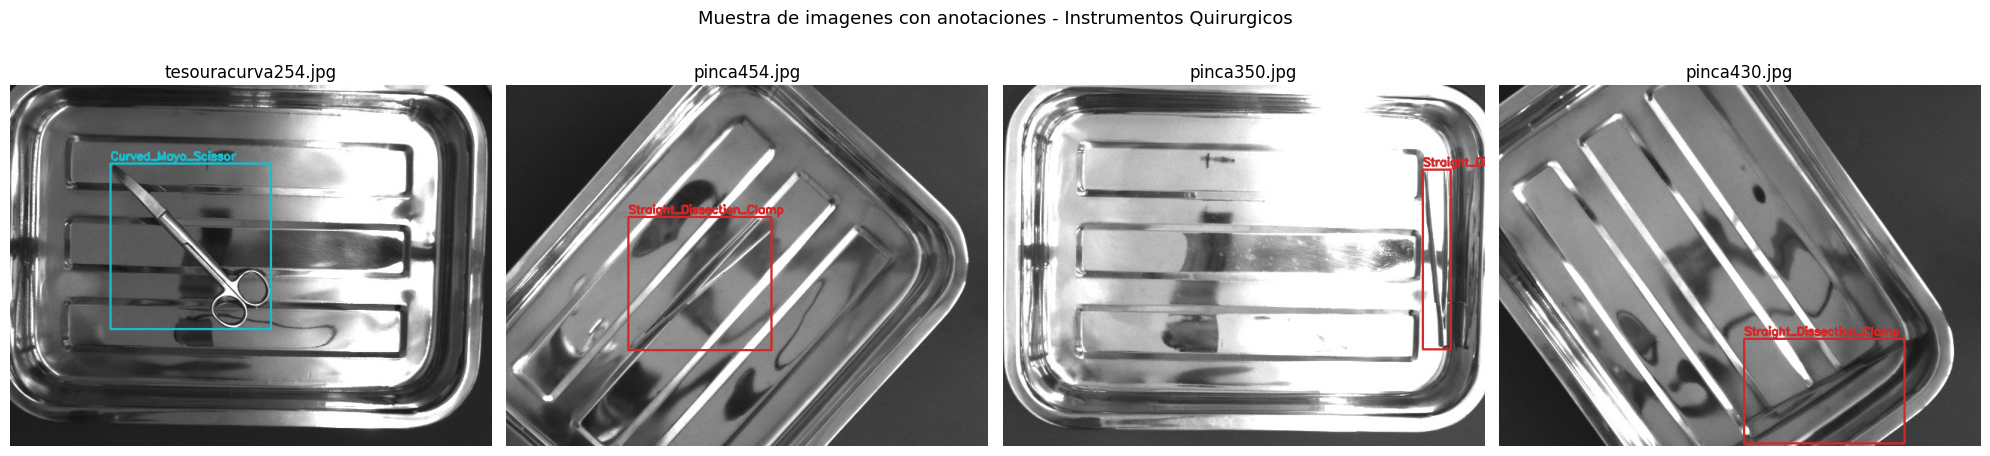

In [16]:
clases = open('classes.txt').read().strip().split('\n')

def leer_label_yolo(label_path, ancho_img, alto_img):
    boxes = []
    with open(label_path, 'r') as f:
        for linea in f.readlines():
            partes = linea.strip().split()
            if len(partes) < 5:
                continue
            clase = int(partes[0])
            cx, cy, w, h = float(partes[1]), float(partes[2]), float(partes[3]), float(partes[4])
            x1 = int((cx - w / 2) * ancho_img)
            y1 = int((cy - h / 2) * alto_img)
            x2 = int((cx + w / 2) * ancho_img)
            y2 = int((cy + h / 2) * alto_img)
            boxes.append((clase, x1, y1, x2, y2))
    return boxes

muestras = random.sample(os.listdir(f'{output_base}/train/images'), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colores = plt.cm.get_cmap('tab10', len(clases))

for ax, nombre_img in zip(axes, muestras):
    ruta_img = f'{output_base}/train/images/{nombre_img}'
    ruta_lbl = f'{output_base}/train/labels/{os.path.splitext(nombre_img)[0]}.txt'

    img = cv2.imread(ruta_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    for (clase, x1, y1, x2, y2) in leer_label_yolo(ruta_lbl, w, h):
        if clase < len(clases):
            color = tuple(int(c * 255) for c in colores(clase)[:3])
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, clases[clase], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    ax.imshow(img)
    ax.set_title(nombre_img[:25])
    ax.axis('off')

plt.suptitle('Muestra de imagenes con anotaciones - Instrumentos Quirurgicos', fontsize=13)
plt.tight_layout()
plt.show()